# Регрессия SI

Этот ноутбук загружает очищенный датафрейм `data/df_clean.csv`, выделяет признаки и целевую переменную `SI`, выполняет предобработку (стандартизация для линейных моделей, без для деревьев), обучает модели регрессии и оценивает их.

## Шаг 1: Загрузка библиотек и данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
import os

In [2]:
file_path = '../data/df_clean.csv'
df = pd.read_csv(file_path)

In [3]:
display(df.head())

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print('Columns:', df.columns.tolist())

Columns: ['IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR

In [5]:
print('Shape:', df.shape)

Shape: (969, 213)


In [6]:
df.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

In [7]:
# Статистика по SI
print("Статистика SI:")
print(df['SI'].describe())

Статистика SI:
count      969.000000
mean        73.967907
std        695.564665
min          0.011489
25%          1.488095
50%          3.900000
75%         16.375000
max      15620.600000
Name: SI, dtype: float64


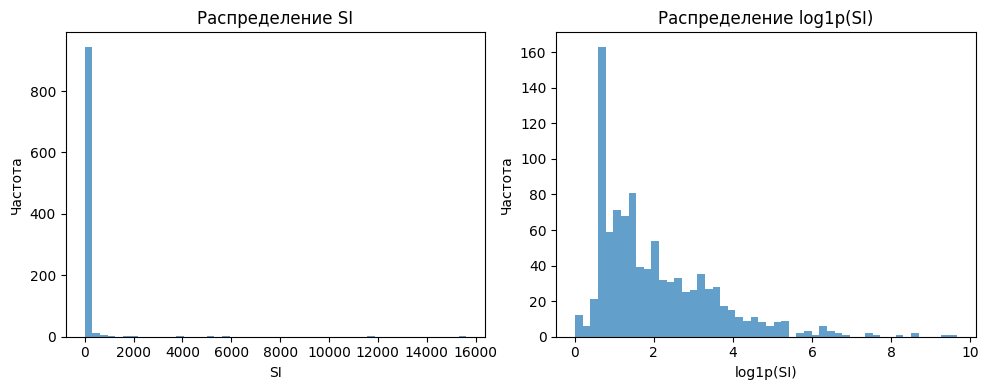

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['SI'], bins=50, alpha=0.7)
plt.title('Распределение SI')
plt.xlabel('SI')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['SI']), bins=50, alpha=0.7)
plt.title('Распределение log1p(SI)')
plt.xlabel('log1p(SI)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

## Шаг 2: Подготовка данных для обучения моделей

### Важный момент
1) SI вычисляется на основе IC50 и CC50, поэтому при моделировании:
    - для задач по SI нельзя использовать IC50 и CC50 как признаки;
    - для задач по IC50  нельзя использовать SI, CC50 как признаки;
    - для задач по CC50  нельзя использовать SI, IC50 как признаки;
2) Для регрессии целевых переменных с сильной асимметрией используется log1p. В этом ноутбуке модель обучается на log1p(SI), и метрики считаются в лог-шкале.
3) Сравнение делается через несколько моделей + кросс-валидацию + подбор гиперпараметров.
4) Все результаты сохраняются в папку reports/, чтобы затем их было удобно включить в отчёт и репозиторий.

In [9]:
# Целевая переменная (логарифмируем из-за большого разброса)
y = np.log1p(df['SI'])

# Признаки — всё, кроме целевых колонок
# ВАЖНО: удаляем SI, чтобы не было утечки данных!
drop_cols = ['CC50, mM', 'IC50, mM', 'SI']
X = df.drop(columns=drop_cols, errors='ignore')

print(f"Признаков: {X.shape[1]}")
print(f"Целевая: log1p(SI)")

Признаков: 210
Целевая: log1p(SI)


РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ


АНАЛИЗ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ


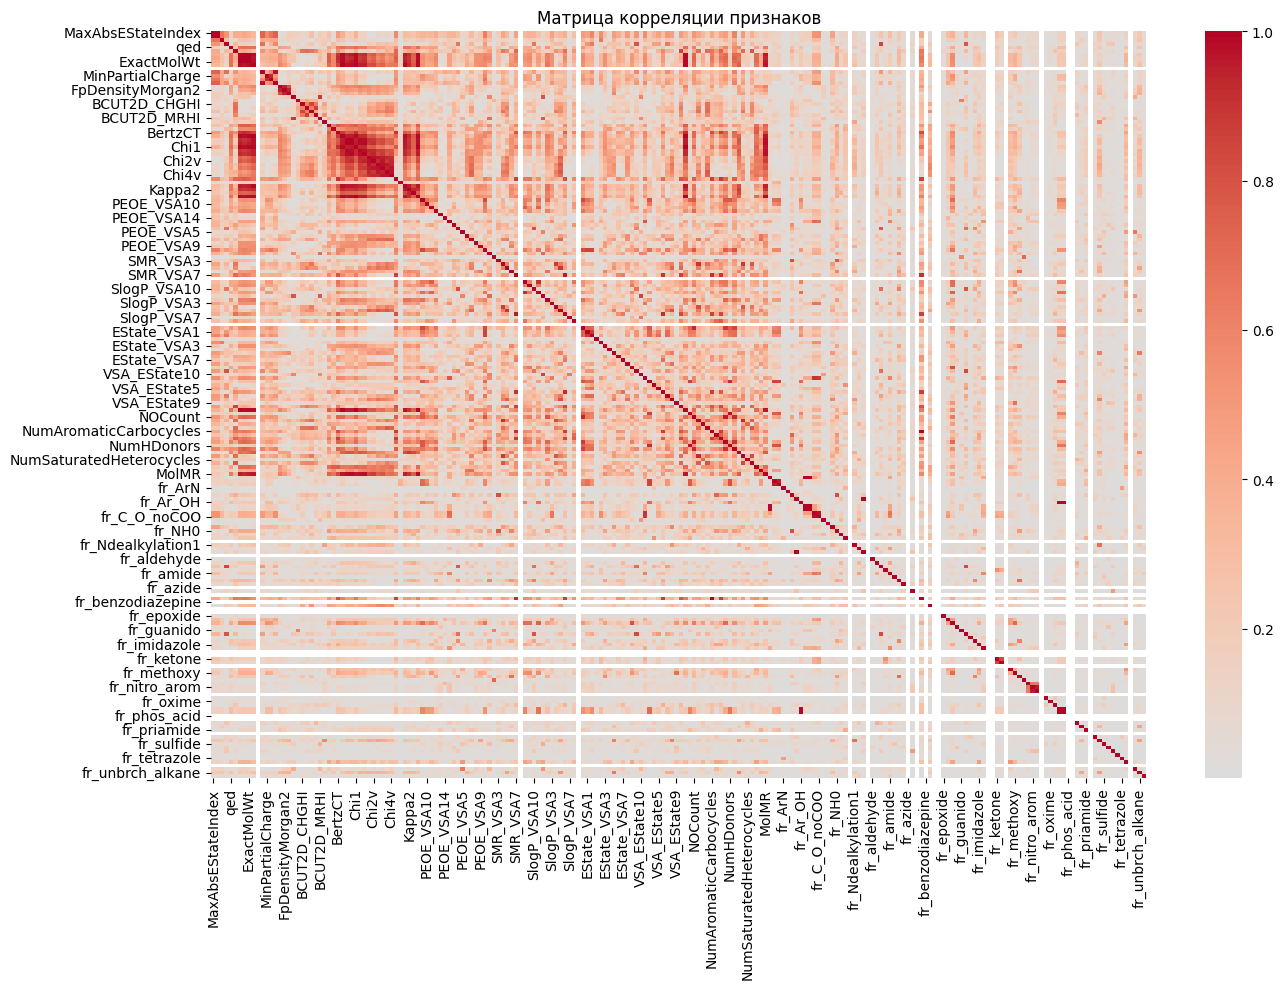

In [10]:
# Анализ и удаление высококоррелированных признаков
print("=" * 60)
print("АНАЛИЗ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ")
print("=" * 60)

# Вычисляем матрицу корреляции
corr_matrix = X.corr().abs()

# Визуализируем корреляцию (heatmap)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

In [11]:
# Находим высококоррелированные пары (>0.9)
correlation_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > correlation_threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(f"\nОбнаружено {len(high_corr_df)} пар признаков с корреляцией > {correlation_threshold}:")
    print(high_corr_df.to_string(index=False))
    
    # Удаляем один из каждой высококоррелированной пары
    cols_to_drop = []
    for pair in high_corr_pairs:
        if pair['Feature 2'] not in cols_to_drop:
            cols_to_drop.append(pair['Feature 2'])
    
    X = X.drop(columns=cols_to_drop)
    print(f"\nУдалены {len(cols_to_drop)} признаков: {cols_to_drop}")
else:
    print(f"\nНет пар признаков с корреляцией > {correlation_threshold}")

print(f"\nОстаток признаков: {X.shape[1]}")
print("=" * 60)


Обнаружено 154 пар признаков с корреляцией > 0.9:
              Feature 1               Feature 2  Correlation
      MaxAbsEStateIndex          MaxEStateIndex     1.000000
               fr_Ar_NH            fr_Nhpyrrole     1.000000
 NumAromaticCarbocycles              fr_benzene     1.000000
              fr_phenol  fr_phenol_noOrthoHbond     1.000000
                 fr_COO                 fr_COO2     1.000000
                  MolWt              ExactMolWt     0.999999
                   Chi1          HeavyAtomCount     0.998736
                  MolWt          HeavyAtomMolWt     0.996861
         HeavyAtomMolWt              ExactMolWt     0.996830
                   Chi0          HeavyAtomCount     0.995968
    NumValenceElectrons                    Chi0     0.994847
              LabuteASA          HeavyAtomCount     0.994362
                   Chi1               LabuteASA     0.992830
                  Chi0n                   Chi0v     0.992684
                   Chi0           

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 775 строк
Тестовая выборка: 194 строк


## Шаг 3: Обучение моделей

In [13]:
os.makedirs('../reports', exist_ok=True) 

In [14]:
models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)), ('model', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=42))]),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# Параметры для подбора (расширенные для лучших результатов)
param_grids = {
    'Ridge': {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
}

param_random = {
    'RandomForest': {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 4, 8],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 0.5, 0.8],
        'bootstrap': [True, False],
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.02, 0.05, 0.1, 0.2],
        'max_depth': [2, 3, 4, 5],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.7, 0.85, 1.0],
        'max_features': ['sqrt', 0.8, None],
    },
}

results = []

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    if name in param_grids:
        search = GridSearchCV(
            model,
            param_grids[name],
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
        )
    elif name in param_random:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_random[name],
            n_iter=32,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            random_state=42,
            refit=True,
        )
    else:
        search = None

    if search is not None:
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        print(f"  Лучшие параметры: {search.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        print(f"  Параметры по умолчанию")
    
    # Предсказания (в лог-шкале)
    y_pred_log = best_model.predict(X_test)
    y_true_log = y_test
    
    # Метрики в лог-шкале (для относительных ошибок)
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae = mean_absolute_error(y_true_log, y_pred_log)
    r2 = r2_score(y_true_log, y_pred_log)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })
    
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")


--- LinearRegression ---
  Параметры по умолчанию
  RMSE: 1.3685
  MAE: 1.0618
  R²: 0.1711

--- Ridge ---
  Лучшие параметры: {'model__alpha': 100.0}
  RMSE: 1.3803
  MAE: 1.0253
  R²: 0.1568

--- RandomForest ---
  Лучшие параметры: {'n_estimators': 600, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
  RMSE: 1.3467
  MAE: 0.9700
  R²: 0.1973

--- GradientBoosting ---
  Лучшие параметры: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.02}
  RMSE: 1.2969
  MAE: 0.9487
  R²: 0.2556


## Шаг 4: Сравнение и сохранение результатов 

In [15]:
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df.to_string(index=False))

# Лучшая модель
best_model_name = results_df.iloc[0]['Model']
best_rmse = float(results_df.iloc[0]['RMSE'])
best_mae = float(results_df.iloc[0]['MAE'])
best_r2 = float(results_df.iloc[0]['R²'])

print(f"\n Лучшая модель: {best_model_name}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"   MAE: {best_mae:.4f}")
print(f"   R²: {best_r2:.4f}")

# Сохраняем в общую таблицу регрессии
summary_file = '../reports/regression_summary.csv'
task_name = 'SI'

if os.path.exists(summary_file):
    summary_df = pd.read_csv(summary_file)
    summary_df = summary_df[summary_df['task'] != task_name]
else:
    summary_df = pd.DataFrame()

new_row = pd.DataFrame([{
    'task': task_name,
    'best_model': best_model_name,
    'RMSE': best_rmse,
    'MAE': best_mae,
    'R2': best_r2
}])

summary_df = pd.concat([summary_df, new_row], ignore_index=True)
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Результат добавлен в {summary_file}")

           Model     RMSE      MAE       R²
GradientBoosting 1.296873 0.948743 0.255613
    RandomForest 1.346674 0.969952 0.197346
LinearRegression 1.368505 1.061782 0.171111
           Ridge 1.380252 1.025326 0.156819

 Лучшая модель: GradientBoosting
   RMSE: 1.2969
   MAE: 0.9487
   R²: 0.2556

✓ Результат добавлен в ../reports/regression_summary.csv
